## 🚦 Road Accident Fatality Risk Prediction
## Introduction

Road traffic accidents are a major public safety concern. Predicting accident severity, especially fatal outcomes, can help policymakers and emergency response teams allocate resources more effectively.

This project analyzes traffic collision data and builds a machine learning model to predict whether an accident is likely to result in a fatal outcome.



## Objective

The primary objective of this project is:

To explore accident severity patterns.

To build a predictive model for fatal vs non-fatal accidents.

To evaluate trade-offs between accuracy and fatal detection.

To deploy the final model using Streamlit for interactive prediction.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 3. Dataset Description

The dataset contains over 770,000 traffic collision records.  
Key attributes include:

- Date and time of accident occurrence  
- Police division  
- Road user involvement (automobile, motorcycle, passenger, bicycle, pedestrian)  
- Injury and fatality indicators  

The dataset provides sufficient scale for machine learning modeling.

## 4. Data Loading and Initial Inspection

The dataset is loaded and initial inspection is performed to understand:
- Column structure
- Data types
- Missing values
- Overall dataset size

In [4]:
dataset = pd.read_csv("../data/raw/Traffic_Collisions_Data.csv")

## 5. Data Cleaning

Data preprocessing steps include:

- Standardizing column names
- Converting date columns to datetime format
- Converting numerical fields (e.g., OCC_HOUR, FATALITIES)
- Handling missing values
- Standardizing categorical YES/NO fields

Proper preprocessing ensures consistency and model reliability.

In [5]:
dataset.columns= dataset.columns.str.strip()
dataset

,OBJECTID,EVENT_UNIQUE_ID,OCC_DATE,OCC_MONTH,OCC_DOW,OCC_YEAR,OCC_HOUR,DIVISION,FATALITIES,INJURY_COLLISIONS,...,NEIGHBOURHOOD_158,LONG_WGS84,LAT_WGS84,AUTOMOBILE,MOTORCYCLE,PASSENGER,BICYCLE,PEDESTRIAN,x,y
0,1,GO-20148000028,1/1/2014 5:00:00 AM,January,Wednesday,2014,17,D53,0,NO,...,Mount Pleasant East (99),-79.377616,43.701225,YES,NO,NO,NO,NO,-8.836276e+06,5.419322e+06
1,2,GO-20148004875,1/1/2014 5:00:00 AM,January,Wednesday,2014,14,D32,0,NO,...,Lawrence Park North (105),-79.397589,43.726091,YES,NO,NO,NO,NO,-8.838499e+06,5.423152e+06
2,3,GO-20141260499,1/1/2014 5:00:00 AM,January,Wednesday,2014,2,NSA,0,YES,...,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09
3,4,GO-20141260663,1/1/2014 5:00:00 AM,January,Wednesday,2014,3,NSA,0,NO,...,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09
4,5,GO-20141261162,1/1/2014 5:00:00 AM,January,Wednesday,2014,5,NSA,0,YES,...,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772511,772512,GO-20252055109,9/30/2025 4:00:00 AM,September,Tuesday,2025,12,D55,0,YES,...,South Riverdale (70),-79.347428,43.659417,YES,NO,NO,YES,NO,-8.832915e+06,5.412887e+06
772512,772513,GO-20252054694,9/30/2025 4:00:00 AM,September,Tuesday,2025,11,D51,0,YES,...,Downtown Yonge East (168),-79.376447,43.654829,YES,NO,NO,YES,NO,-8.836146e+06,5.412181e+06
772513,772514,GO-20252054674,9/30/2025 4:00:00 AM,September,Tuesday,2025,11,D55,0,YES,...,South Riverdale (70),-79.328288,43.658981,YES,NO,NO,NO,NO,-8.830785e+06,5.412819e+06
772514,772515,GO-20258044297,9/30/2025 4:00:00 AM,September,Tuesday,2025,19,D22,0,NO,...,Etobicoke City Centre (159),-79.532833,43.643153,YES,NO,NO,NO,NO,-8.853554e+06,5.410384e+06


In [6]:
print(f"Initial shape {dataset.shape}")
print(f"Total number of Rows: {dataset.shape[0]}")
print(f"Total number of Columns: {dataset.shape[1]}")
dataset.head(3)

Initial shape (772516, 23)
Total number of Rows: 772516
Total number of Columns: 23


,OBJECTID,EVENT_UNIQUE_ID,OCC_DATE,OCC_MONTH,OCC_DOW,OCC_YEAR,OCC_HOUR,DIVISION,FATALITIES,INJURY_COLLISIONS,...,NEIGHBOURHOOD_158,LONG_WGS84,LAT_WGS84,AUTOMOBILE,MOTORCYCLE,PASSENGER,BICYCLE,PEDESTRIAN,x,y
0,1,GO-20148000028,1/1/2014 5:00:00 AM,January,Wednesday,2014,17,D53,0,NO,...,Mount Pleasant East (99),-79.377616,43.701225,YES,NO,NO,NO,NO,-8.836276e+06,5.419322e+06
1,2,GO-20148004875,1/1/2014 5:00:00 AM,January,Wednesday,2014,14,D32,0,NO,...,Lawrence Park North (105),-79.397589,43.726091,YES,NO,NO,NO,NO,-8.838499e+06,5.423152e+06
2,3,GO-20141260499,1/1/2014 5:00:00 AM,January,Wednesday,2014,2,NSA,0,YES,...,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09


In [7]:
dataset.loc[100:400]

,OBJECTID,EVENT_UNIQUE_ID,OCC_DATE,OCC_MONTH,OCC_DOW,OCC_YEAR,OCC_HOUR,DIVISION,FATALITIES,INJURY_COLLISIONS,...,NEIGHBOURHOOD_158,LONG_WGS84,LAT_WGS84,AUTOMOBILE,MOTORCYCLE,PASSENGER,BICYCLE,PEDESTRIAN,x,y
100,101,GO-20141268582,1/2/2014 5:00:00 AM,January,Thursday,2014,16,D14,0,NO,...,Trinity-Bellwoods (81),-79.421480,43.654650,YES,NO,NO,NO,NO,-8.841159e+06,5.412153e+06
101,102,GO-20141268521,1/2/2014 5:00:00 AM,January,Thursday,2014,15,D13,0,NO,...,Humewood-Cedarvale (106),-79.421428,43.684437,YES,NO,NO,NO,NO,-8.841153e+06,5.416737e+06
102,103,GO-20148000202,1/2/2014 5:00:00 AM,January,Thursday,2014,19,NSA,0,NO,...,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09
103,104,GO-20148000290,1/2/2014 5:00:00 AM,January,Thursday,2014,12,D53,0,NO,...,Yonge-Eglinton (100),-79.408485,43.704623,YES,NO,NO,NO,NO,-8.839712e+06,5.419845e+06
104,105,GO-20141268493,1/2/2014 5:00:00 AM,January,Thursday,2014,15,D55,0,NO,...,South Riverdale (70),-79.336212,43.665406,YES,NO,NO,NO,NO,-8.831667e+06,5.413808e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396,397,GO-20148000223,1/3/2014 5:00:00 AM,January,Friday,2014,14,D41,0,NO,...,Wexford/Maryvale (119),-79.304451,43.760353,YES,NO,NO,NO,NO,-8.828131e+06,5.428431e+06
397,398,GO-20148000224,1/3/2014 5:00:00 AM,January,Friday,2014,13,D42,0,NO,...,Tam O'Shanter-Sullivan (118),-79.307906,43.778734,YES,NO,NO,NO,NO,-8.828516e+06,5.431264e+06
398,399,GO-20148000225,1/3/2014 5:00:00 AM,January,Friday,2014,14,D53,0,NO,...,North Toronto (173),-79.394125,43.707598,N/R,N/R,N/R,N/R,N/R,-8.838114e+06,5.420303e+06
399,400,GO-20148000227,1/3/2014 5:00:00 AM,January,Friday,2014,14,D43,0,NO,...,West Hill (136),-79.194667,43.761980,YES,NO,NO,NO,NO,-8.815910e+06,5.428682e+06


In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 772516 entries, 0 to 772515
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   OBJECTID           772516 non-null  int64  
 1   EVENT_UNIQUE_ID    772516 non-null  object 
 2   OCC_DATE           772516 non-null  object 
 3   OCC_MONTH          772516 non-null  object 
 4   OCC_DOW            772516 non-null  object 
 5   OCC_YEAR           772516 non-null  int64  
 6   OCC_HOUR           772516 non-null  int64  
 7   DIVISION           772516 non-null  object 
 8   FATALITIES         772516 non-null  int64  
 9   INJURY_COLLISIONS  772512 non-null  object 
 10  FTR_COLLISIONS     772512 non-null  object 
 11  PD_COLLISIONS      772512 non-null  object 
 12  HOOD_158           772516 non-null  object 
 13  NEIGHBOURHOOD_158  772516 non-null  object 
 14  LONG_WGS84         772516 non-null  float64
 15  LAT_WGS84          772516 non-null  float64
 16  AU

In [9]:
dataset['OCC_DATE']=pd.to_datetime(dataset['OCC_DATE'],errors = 'coerce')
dataset['OCC_DATE'].isna().sum()

0

In [10]:


dataset["OCC_HOUR"] = pd.to_numeric(dataset["OCC_HOUR"], errors="coerce")
dataset['FATALITIES']=pd.to_numeric(dataset['FATALITIES'],errors='coerce').fillna(0)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 772516 entries, 0 to 772515
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   OBJECTID           772516 non-null  int64         
 1   EVENT_UNIQUE_ID    772516 non-null  object        
 2   OCC_DATE           772516 non-null  datetime64[ns]
 3   OCC_MONTH          772516 non-null  object        
 4   OCC_DOW            772516 non-null  object        
 5   OCC_YEAR           772516 non-null  int64         
 6   OCC_HOUR           772516 non-null  int64         
 7   DIVISION           772516 non-null  object        
 8   FATALITIES         772516 non-null  int64         
 9   INJURY_COLLISIONS  772512 non-null  object        
 10  FTR_COLLISIONS     772512 non-null  object        
 11  PD_COLLISIONS      772512 non-null  object        
 12  HOOD_158           772516 non-null  object        
 13  NEIGHBOURHOOD_158  772516 non-null  object  

In [11]:
yes_no = [
    "INJURY_COLLISIONS","FTR_COLLISIONS","PD_COLLISIONS",
    "AUTOMOBILE","MOTORCYCLE","PASSENGER","BICYCLE","PEDESTRIAN"
]

for c in yes_no:
    if c in dataset.columns:
        dataset[c]=dataset[c].str.strip().str.upper()
dataset


,OBJECTID,EVENT_UNIQUE_ID,OCC_DATE,OCC_MONTH,OCC_DOW,OCC_YEAR,OCC_HOUR,DIVISION,FATALITIES,INJURY_COLLISIONS,...,NEIGHBOURHOOD_158,LONG_WGS84,LAT_WGS84,AUTOMOBILE,MOTORCYCLE,PASSENGER,BICYCLE,PEDESTRIAN,x,y
0,1,GO-20148000028,2014-01-01 05:00:00,January,Wednesday,2014,17,D53,0,NO,...,Mount Pleasant East (99),-79.377616,43.701225,YES,NO,NO,NO,NO,-8.836276e+06,5.419322e+06
1,2,GO-20148004875,2014-01-01 05:00:00,January,Wednesday,2014,14,D32,0,NO,...,Lawrence Park North (105),-79.397589,43.726091,YES,NO,NO,NO,NO,-8.838499e+06,5.423152e+06
2,3,GO-20141260499,2014-01-01 05:00:00,January,Wednesday,2014,2,NSA,0,YES,...,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09
3,4,GO-20141260663,2014-01-01 05:00:00,January,Wednesday,2014,3,NSA,0,NO,...,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09
4,5,GO-20141261162,2014-01-01 05:00:00,January,Wednesday,2014,5,NSA,0,YES,...,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772511,772512,GO-20252055109,2025-09-30 04:00:00,September,Tuesday,2025,12,D55,0,YES,...,South Riverdale (70),-79.347428,43.659417,YES,NO,NO,YES,NO,-8.832915e+06,5.412887e+06
772512,772513,GO-20252054694,2025-09-30 04:00:00,September,Tuesday,2025,11,D51,0,YES,...,Downtown Yonge East (168),-79.376447,43.654829,YES,NO,NO,YES,NO,-8.836146e+06,5.412181e+06
772513,772514,GO-20252054674,2025-09-30 04:00:00,September,Tuesday,2025,11,D55,0,YES,...,South Riverdale (70),-79.328288,43.658981,YES,NO,NO,NO,NO,-8.830785e+06,5.412819e+06
772514,772515,GO-20258044297,2025-09-30 04:00:00,September,Tuesday,2025,19,D22,0,NO,...,Etobicoke City Centre (159),-79.532833,43.643153,YES,NO,NO,NO,NO,-8.853554e+06,5.410384e+06


In [12]:
dataset=dataset.dropna(subset=["OCC_DATE","OCC_HOUR","OCC_DOW","OCC_MONTH","DIVISION"])
dataset = dataset.reset_index(drop=True)
dataset

,OBJECTID,EVENT_UNIQUE_ID,OCC_DATE,OCC_MONTH,OCC_DOW,OCC_YEAR,OCC_HOUR,DIVISION,FATALITIES,INJURY_COLLISIONS,...,NEIGHBOURHOOD_158,LONG_WGS84,LAT_WGS84,AUTOMOBILE,MOTORCYCLE,PASSENGER,BICYCLE,PEDESTRIAN,x,y
0,1,GO-20148000028,2014-01-01 05:00:00,January,Wednesday,2014,17,D53,0,NO,...,Mount Pleasant East (99),-79.377616,43.701225,YES,NO,NO,NO,NO,-8.836276e+06,5.419322e+06
1,2,GO-20148004875,2014-01-01 05:00:00,January,Wednesday,2014,14,D32,0,NO,...,Lawrence Park North (105),-79.397589,43.726091,YES,NO,NO,NO,NO,-8.838499e+06,5.423152e+06
2,3,GO-20141260499,2014-01-01 05:00:00,January,Wednesday,2014,2,NSA,0,YES,...,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09
3,4,GO-20141260663,2014-01-01 05:00:00,January,Wednesday,2014,3,NSA,0,NO,...,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09
4,5,GO-20141261162,2014-01-01 05:00:00,January,Wednesday,2014,5,NSA,0,YES,...,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772511,772512,GO-20252055109,2025-09-30 04:00:00,September,Tuesday,2025,12,D55,0,YES,...,South Riverdale (70),-79.347428,43.659417,YES,NO,NO,YES,NO,-8.832915e+06,5.412887e+06
772512,772513,GO-20252054694,2025-09-30 04:00:00,September,Tuesday,2025,11,D51,0,YES,...,Downtown Yonge East (168),-79.376447,43.654829,YES,NO,NO,YES,NO,-8.836146e+06,5.412181e+06
772513,772514,GO-20252054674,2025-09-30 04:00:00,September,Tuesday,2025,11,D55,0,YES,...,South Riverdale (70),-79.328288,43.658981,YES,NO,NO,NO,NO,-8.830785e+06,5.412819e+06
772514,772515,GO-20258044297,2025-09-30 04:00:00,September,Tuesday,2025,19,D22,0,NO,...,Etobicoke City Centre (159),-79.532833,43.643153,YES,NO,NO,NO,NO,-8.853554e+06,5.410384e+06


## 6. Target Variable Engineering

Initially, accident severity was categorized into three levels:

- 0 → Property Damage  
- 1 → Injury  
- 2 → Fatal  

For deployment and practical modeling, the problem was reformulated into a binary classification task:

- 0 → Non-Fatal  
- 1 → Fatal  

Fatal cases were identified using:
- FATALITIES > 0  
- OR FTR_COLLISIONS == "YES"

In [13]:
def create_severity(row):
    if row['FATALITIES']>0 or row['FTR_COLLISIONS']=='YES':
        return 2
    elif row['INJURY_COLLISIONS']=='YES':
        return 1
    else:
        return 0
dataset['ACCIDENT_SEVERITY']= dataset.apply(create_severity,axis=1)
print(f"Severity\n Fatal = 2\n Injury = 1 \n propery damage only = 0")

Severity
 Fatal = 2
 Injury = 1 
 propery damage only = 0


In [14]:
dataset['ACCIDENT_SEVERITY'].value_counts().sort_index()

ACCIDENT_SEVERITY
0    538731
1    101228
2    132557
Name: count, dtype: int64

In [15]:
dataset.dropna(inplace=True)
dataset.isna().sum()

OBJECTID             0
EVENT_UNIQUE_ID      0
OCC_DATE             0
OCC_MONTH            0
OCC_DOW              0
OCC_YEAR             0
OCC_HOUR             0
DIVISION             0
FATALITIES           0
INJURY_COLLISIONS    0
FTR_COLLISIONS       0
PD_COLLISIONS        0
HOOD_158             0
NEIGHBOURHOOD_158    0
LONG_WGS84           0
LAT_WGS84            0
AUTOMOBILE           0
MOTORCYCLE           0
PASSENGER            0
BICYCLE              0
PEDESTRIAN           0
x                    0
y                    0
ACCIDENT_SEVERITY    0
dtype: int64

In [16]:
dataset.dtypes


OBJECTID                      int64
EVENT_UNIQUE_ID              object
OCC_DATE             datetime64[ns]
OCC_MONTH                    object
OCC_DOW                      object
OCC_YEAR                      int64
OCC_HOUR                      int64
DIVISION                     object
FATALITIES                    int64
INJURY_COLLISIONS            object
FTR_COLLISIONS               object
PD_COLLISIONS                object
HOOD_158                     object
NEIGHBOURHOOD_158            object
LONG_WGS84                  float64
LAT_WGS84                   float64
AUTOMOBILE                   object
MOTORCYCLE                   object
PASSENGER                    object
BICYCLE                      object
PEDESTRIAN                   object
x                           float64
y                           float64
ACCIDENT_SEVERITY             int64
dtype: object

In [17]:
dataset

,OBJECTID,EVENT_UNIQUE_ID,OCC_DATE,OCC_MONTH,OCC_DOW,OCC_YEAR,OCC_HOUR,DIVISION,FATALITIES,INJURY_COLLISIONS,...,LONG_WGS84,LAT_WGS84,AUTOMOBILE,MOTORCYCLE,PASSENGER,BICYCLE,PEDESTRIAN,x,y,ACCIDENT_SEVERITY
0,1,GO-20148000028,2014-01-01 05:00:00,January,Wednesday,2014,17,D53,0,NO,...,-79.377616,43.701225,YES,NO,NO,NO,NO,-8.836276e+06,5.419322e+06,2
1,2,GO-20148004875,2014-01-01 05:00:00,January,Wednesday,2014,14,D32,0,NO,...,-79.397589,43.726091,YES,NO,NO,NO,NO,-8.838499e+06,5.423152e+06,0
2,3,GO-20141260499,2014-01-01 05:00:00,January,Wednesday,2014,2,NSA,0,YES,...,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09,1
3,4,GO-20141260663,2014-01-01 05:00:00,January,Wednesday,2014,3,NSA,0,NO,...,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09,0
4,5,GO-20141261162,2014-01-01 05:00:00,January,Wednesday,2014,5,NSA,0,YES,...,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772511,772512,GO-20252055109,2025-09-30 04:00:00,September,Tuesday,2025,12,D55,0,YES,...,-79.347428,43.659417,YES,NO,NO,YES,NO,-8.832915e+06,5.412887e+06,1
772512,772513,GO-20252054694,2025-09-30 04:00:00,September,Tuesday,2025,11,D51,0,YES,...,-79.376447,43.654829,YES,NO,NO,YES,NO,-8.836146e+06,5.412181e+06,1
772513,772514,GO-20252054674,2025-09-30 04:00:00,September,Tuesday,2025,11,D55,0,YES,...,-79.328288,43.658981,YES,NO,NO,NO,NO,-8.830785e+06,5.412819e+06,1
772514,772515,GO-20258044297,2025-09-30 04:00:00,September,Tuesday,2025,19,D22,0,NO,...,-79.532833,43.643153,YES,NO,NO,NO,NO,-8.853554e+06,5.410384e+06,0


Text(0.5, 1.0, 'Total Accidents by Hour')

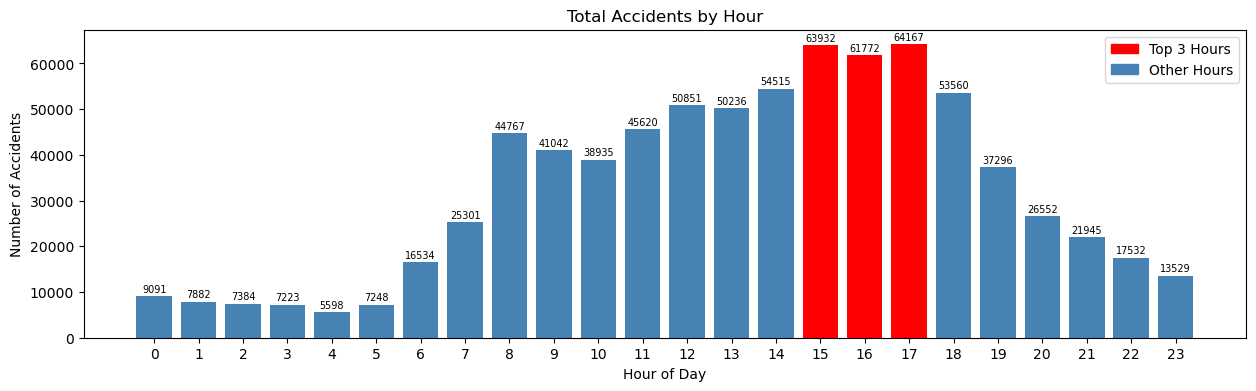

In [18]:
acc_by_hour=dataset['OCC_HOUR'].value_counts().sort_index()

top3 = dataset['OCC_HOUR'].value_counts().sort_values(ascending=False).head(3)
colour = []
for i in acc_by_hour.index:
    if i in top3.index:
        colour.append('red')
    else:
        colour.append('steelblue')

plt.figure(figsize=(15,4))
plt.bar(acc_by_hour.index,acc_by_hour.values,color=colour)
for x,y in zip(acc_by_hour.index,acc_by_hour.values):
    plt.text(x,y+900,y,ha='center',fontsize=7)
plt.xticks(range(0,24))
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
import matplotlib.patches as mpatches
top_patch = mpatches.Patch(color='red', label='Top 3 Hours')
normal_patch = mpatches.Patch(color='steelblue', label='Other Hours')
plt.legend(handles=[top_patch, normal_patch])
plt.title("Total Accidents by Hour")

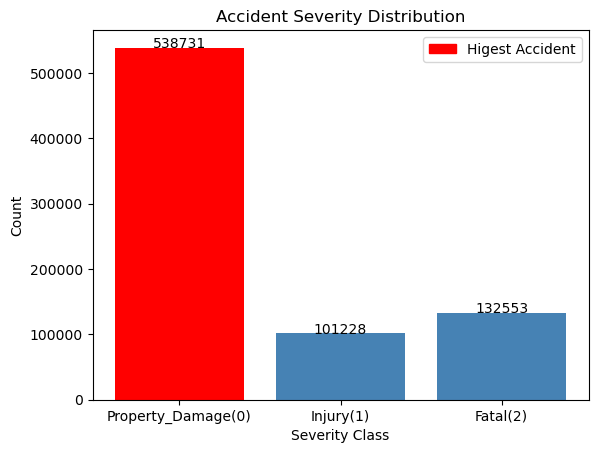

In [19]:
sev_counts = dataset["ACCIDENT_SEVERITY"].value_counts().sort_index()
title = ['Property_Damage(0)','Injury(1)','Fatal(2)']
plt.figure()
plt.bar(title, sev_counts.values,color=["Red","steelblue","steelblue"])
for x,y in zip(title,sev_counts.values):
    plt.text(x,y,y,ha='center')
plt.xlabel("Severity Class")
plt.ylabel("Count")
plt.xticks(range(0,3))
top = mpatches.Patch(color='Red',label = 'Higest Accident')
plt.legend(handles=[top])
plt.title("Accident Severity Distribution")
plt.show()

In [20]:
dataset.columns

Index(['OBJECTID', 'EVENT_UNIQUE_ID', 'OCC_DATE', 'OCC_MONTH', 'OCC_DOW',
       'OCC_YEAR', 'OCC_HOUR', 'DIVISION', 'FATALITIES', 'INJURY_COLLISIONS',
       'FTR_COLLISIONS', 'PD_COLLISIONS', 'HOOD_158', 'NEIGHBOURHOOD_158',
       'LONG_WGS84', 'LAT_WGS84', 'AUTOMOBILE', 'MOTORCYCLE', 'PASSENGER',
       'BICYCLE', 'PEDESTRIAN', 'x', 'y', 'ACCIDENT_SEVERITY'],
      dtype='object')

NEIGHBOURHOOD_158
NSA                                            126069
Wexford/Maryvale (119)                          18988
West Humber-Clairville (1)                      15621
York University Heights (27)                    12757
St Lawrence-East Bayfront-The Islands (166)     10861
Name: count, dtype: int64


Text(0.5, 0, 'count of Accidents')

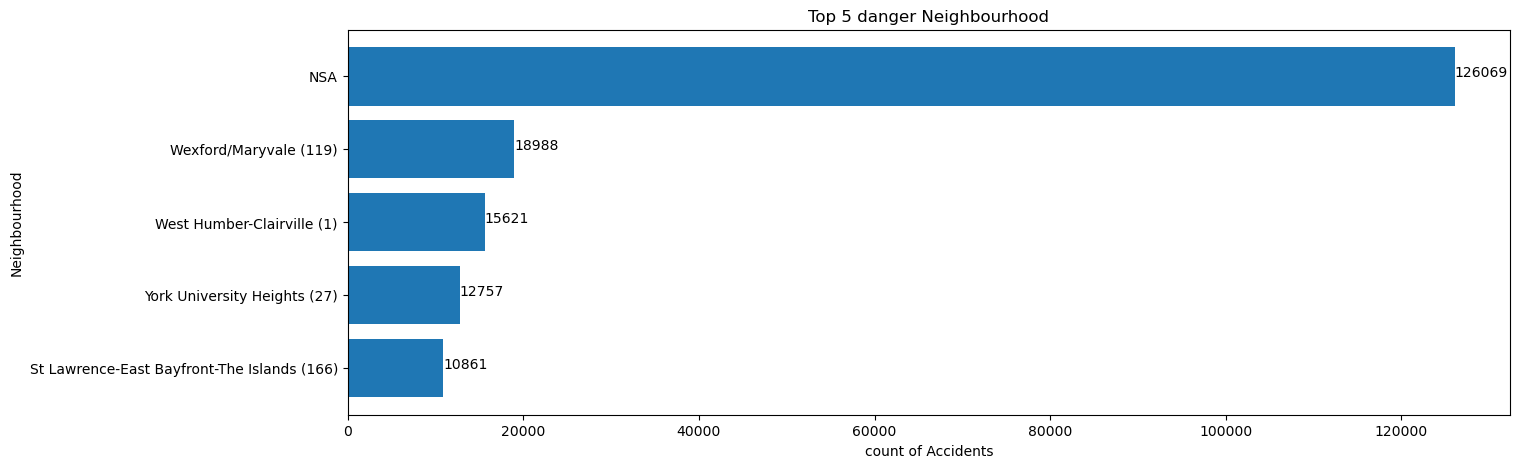

In [21]:
places = dataset['NEIGHBOURHOOD_158'].value_counts().sort_values(
   ascending=False 
).head()
print(places)
plt.figure(figsize=(15,5))
plt.barh(places.index,places.values)
for x,y in zip(places.index,places.values):
    plt.text(y,x,y)
plt.gca().invert_yaxis()
plt.title("Top 5 danger Neighbourhood")
plt.ylabel("Neighbourhood")
plt.xlabel("count of Accidents")

Text(0.5, 1.0, 'Average of Accident Severity by Neighbourhood')

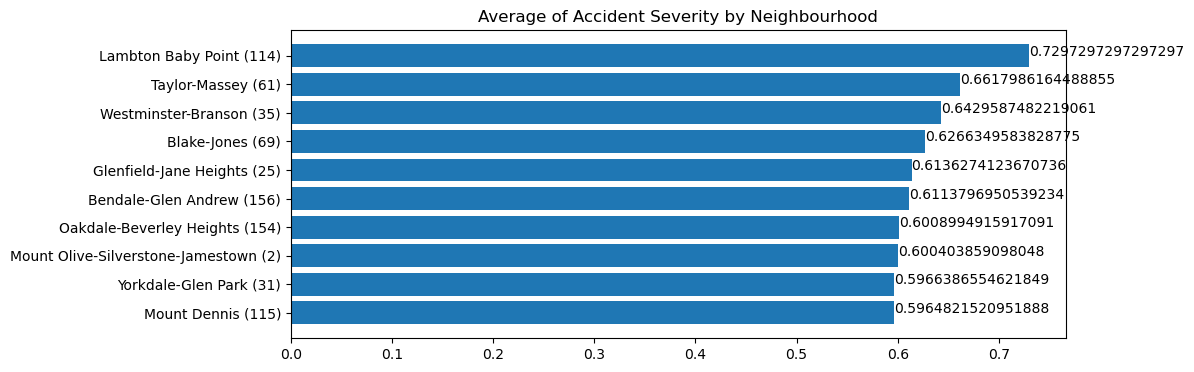

In [22]:
top_location=dataset.groupby('NEIGHBOURHOOD_158')["ACCIDENT_SEVERITY"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize = (10,4))
plt.barh(top_location.index,top_location.values)
for x,y in zip(top_location.index,top_location.values):
    plt.text(y,x,y)
plt.gca().invert_yaxis()
plt.title("Average of Accident Severity by Neighbourhood")

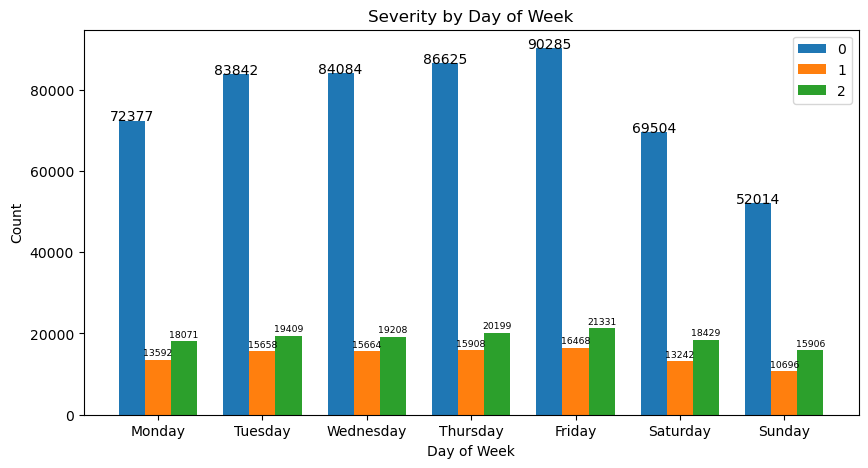

In [23]:
bob =dataset.groupby(['OCC_DOW','ACCIDENT_SEVERITY']).size().unstack(fill_value=0)
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
ordered = []
for i in dow_order:
    if i in bob.index:
        ordered.append(i)
ordered_data = bob.reindex(ordered)
ordered_data
temp_index=np.arange(len(ordered_data.index))
plt.figure(figsize=(10,5))
plt.bar(temp_index-0.25,ordered_data[0],width = 0.25,label = '0')
plt.bar(temp_index,ordered_data[1],width = 0.25, label ='1')
plt.bar(temp_index+0.25,ordered_data[2],width=0.25, label = '2')
for x,y in zip(temp_index-0.25,ordered_data[0]):
    plt.text(x,y,y,ha ='center')
for x,y in zip(temp_index,ordered_data[1]):
    plt.text(x,y+990,y,ha ='center',fontsize = 6.7)
for x,y in zip(temp_index+0.25,ordered_data[2]):
    plt.text(x,y+990,y,ha ='center',fontsize = 6.7)
plt.xticks(temp_index,ordered_data.index)
plt.legend()
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.title("Severity by Day of Week")
plt.show()


AUTOMOBILE


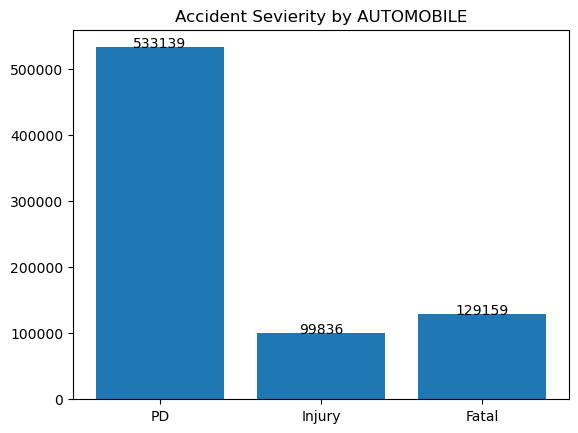

PEDESTRIAN


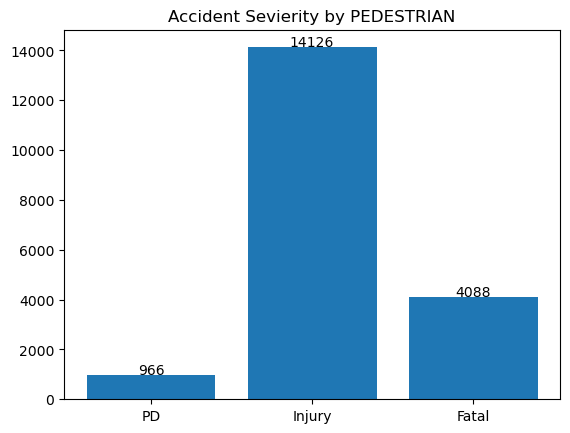

BICYCLE


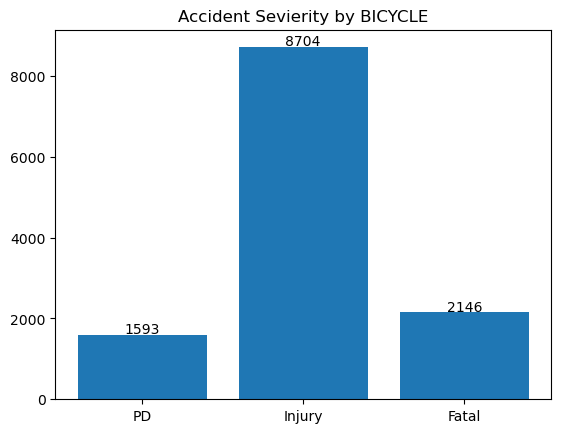

MOTORCYCLE


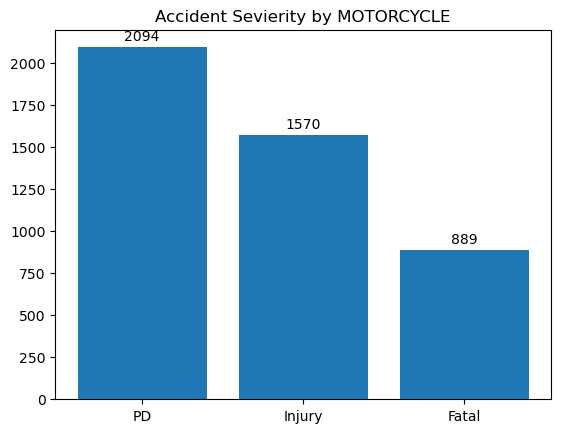

PASSENGER


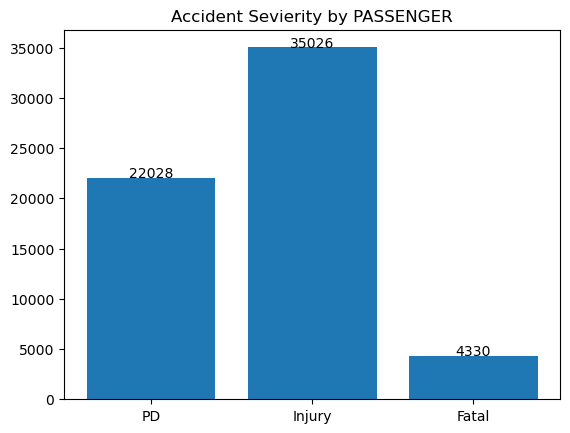

In [24]:
list= ["AUTOMOBILE","PEDESTRIAN","BICYCLE","MOTORCYCLE","PASSENGER"]
for user in list:
    user_data=dataset[dataset[user]=='YES']
    tempp =user_data['ACCIDENT_SEVERITY'].value_counts().sort_index()
    plt.bar(['PD','Injury','Fatal'],tempp.values)
    for x,y in zip(tempp.index,tempp.values):
        plt.text(x,y+40,y,ha='center')
            
    print(user)
    plt.title(f"Accident Sevierity by {user}")
    plt.show()

In [25]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt

Feature Engineering

To improve predictive performance, additional contextual features were engineered:

- IS_NIGHT → accidents between 8PM–5AM
- IS_WEEKEND → Saturday or Sunday
- RUSH_HOUR → peak traffic hours (7–9AM, 4–6PM)

These features allow the model to capture temporal risk patterns associated with accident severity.

In [26]:
dataset["IS_NIGHT"] = ((dataset["OCC_HOUR"] >= 20) | (dataset["OCC_HOUR"] <= 5)).astype(int)
dataset["IS_WEEKEND"] = dataset["OCC_DOW"].isin(["Saturday","Sunday"]).astype(int)
dataset["RUSH_HOUR"] = ((dataset["OCC_HOUR"].between(7,9)) | (dataset["OCC_HOUR"].between(16,18))).astype(int)

## 6. Target Variable Engineering

Initially, accident severity was categorized into three levels:

- 0 → Property Damage  
- 1 → Injury  
- 2 → Fatal  

For deployment and practical modeling, the problem was reformulated into a binary classification task:

- 0 → Non-Fatal  
- 1 → Fatal  

Fatal cases were identified using:
- FATALITIES > 0  
- OR FTR_COLLISIONS == "YES"

In [27]:
def create_severity(row):
    if row["FATALITIES"] > 0 or row.get("FTR_COLLISIONS","NO") == "YES":
        return 2
    elif row.get("INJURY_COLLISIONS","NO") == "YES":
        return 1
    else:
        return 0

dataset["ACCIDENT_SEVERITY"] = dataset.apply(create_severity, axis=1)
dataset["FATAL_BINARY"] = (dataset["ACCIDENT_SEVERITY"] == 2).astype(int)

dataset["FATAL_BINARY"].value_counts()

FATAL_BINARY
0    639959
1    132553
Name: count, dtype: int64

## 7. Class Imbalance Analysis

The dataset is highly imbalanced:

- ~83% Non-Fatal accidents  
- ~17% Fatal accidents  

Due to this imbalance, accuracy alone is not an appropriate evaluation metric.

The analysis therefore focuses on:

- Recall (ability to detect fatal cases)
- Precision (false alarm control)
- Precision–Recall curve
- Threshold calibration

In [28]:
features = [
    "OCC_HOUR","OCC_DOW","OCC_MONTH","OCC_YEAR",
    "DIVISION",
    "AUTOMOBILE","MOTORCYCLE","PASSENGER","BICYCLE","PEDESTRIAN",
    "IS_NIGHT","IS_WEEKEND","RUSH_HOUR"
]
features = [c for c in features if c in dataset.columns]

X = dataset[features].copy()
y = dataset["FATAL_BINARY"].copy()

X.shape, y.shape

((772512, 13), (772512,))

In [29]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes :", X_test.shape, y_test.shape)

print("\nClass distribution in FULL data:")
print(y.value_counts(normalize=True).sort_index())

print("\nClass distribution in TRAIN:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nClass distribution in TEST:")
print(y_test.value_counts(normalize=True).sort_index())


Train shapes: (618009, 13) (618009,)
Test shapes : (154503, 13) (154503,)

Class distribution in FULL data:
FATAL_BINARY
0    0.828413
1    0.171587
Name: proportion, dtype: float64

Class distribution in TRAIN:
FATAL_BINARY
0    0.828414
1    0.171586
Name: proportion, dtype: float64

Class distribution in TEST:
FATAL_BINARY
0    0.828411
1    0.171589
Name: proportion, dtype: float64


In [30]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = ["OCC_HOUR","OCC_YEAR","IS_NIGHT","IS_WEEKEND","RUSH_HOUR"]


categorical_features = [c for c in X.columns if c not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

Numeric features: ['OCC_HOUR', 'OCC_YEAR', 'IS_NIGHT', 'IS_WEEKEND', 'RUSH_HOUR']
Categorical features: ['OCC_DOW', 'OCC_MONTH', 'DIVISION', 'AUTOMOBILE', 'MOTORCYCLE', 'PASSENGER', 'BICYCLE', 'PEDESTRIAN']


# Logistic Regression


In [31]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

baseline = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)
y_proba_base = baseline.predict_proba(X_test)[:,1]

print("=== Logistic Regression Baseline ===")
print(classification_report(y_test, y_pred_base, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_base))

=== Logistic Regression Baseline ===
              precision    recall  f1-score   support

           0      0.859     0.596     0.704    127992
           1      0.213     0.529     0.304     26511

    accuracy                          0.584    154503
   macro avg      0.536     0.562     0.504    154503
weighted avg      0.748     0.584     0.635    154503

ROC-AUC: 0.5932497252460441


# Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=16,
        random_state=42,
        n_jobs=-1,
        class_weight={0:1, 1:3} 
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:,1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0      0.839     0.958     0.894    127992
           1      0.352     0.110     0.167     26511

    accuracy                          0.813    154503
   macro avg      0.595     0.534     0.531    154503
weighted avg      0.755     0.813     0.770    154503

ROC-AUC: 0.6282792421329547


# Random Forest (Higher Fatal Weight)

In [ ]:
rf_model2 = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=250,
        max_depth=18,
        random_state=42,
        n_jobs=-1,
        class_weight={0:1, 1:5} 
    ))
])

rf_model2.fit(X_train, y_train)

y_pred_rf2 = rf_model2.predict(X_test)
y_proba_rf2 = rf_model2.predict_proba(X_test)[:,1]

print("=== Random Forest (Higher Fatal Weight) ===")
print(classification_report(y_test, y_pred_rf2, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf2))

In [ ]:
y_proba = y_proba_rf  

for th in [0.3, 0.4, 0.5, 0.6]:
    y_pred_th = (y_proba >= th).astype(int)
    print("\nThreshold =", th)
    print(classification_report(y_test, y_pred_th, digits=3))


Threshold = 0.3
              precision    recall  f1-score   support

           0      0.931     0.160     0.273    127992
           1      0.189     0.943     0.314     26511

    accuracy                          0.294    154503
   macro avg      0.560     0.551     0.294    154503
weighted avg      0.804     0.294     0.280    154503


Threshold = 0.4
              precision    recall  f1-score   support

           0      0.862     0.726     0.788    127992
           1      0.249     0.438     0.318     26511

    accuracy                          0.677    154503
   macro avg      0.555     0.582     0.553    154503
weighted avg      0.757     0.677     0.707    154503


Threshold = 0.5
              precision    recall  f1-score   support

           0      0.839     0.958     0.894    127992
           1      0.352     0.110     0.167     26511

    accuracy                          0.813    154503
   macro avg      0.595     0.534     0.531    154503
weighted avg      0.755

# Xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

xgb_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

=== XGBoost ===
              precision    recall  f1-score   support

           0      0.831     0.997     0.906    127992
           1      0.572     0.022     0.042     26511

    accuracy                          0.829    154503
   macro avg      0.701     0.509     0.474    154503
weighted avg      0.787     0.829     0.758    154503

ROC-AUC: 0.6362077220078886


In [ ]:
for th in [0.3, 0.4, 0.5, 0.6]:
    y_pred_th = (y_proba_xgb >= th).astype(int)
    print("\nThreshold =", th)
    print(classification_report(y_test, y_pred_th, digits=3))


Threshold = 0.3
              precision    recall  f1-score   support

           0      0.838     0.963     0.896    127992
           1      0.366     0.103     0.161     26511

    accuracy                          0.816    154503
   macro avg      0.602     0.533     0.529    154503
weighted avg      0.757     0.816     0.770    154503


Threshold = 0.4
              precision    recall  f1-score   support

           0      0.833     0.991     0.905    127992
           1      0.489     0.044     0.080     26511

    accuracy                          0.828    154503
   macro avg      0.661     0.517     0.493    154503
weighted avg      0.774     0.828     0.764    154503


Threshold = 0.5
              precision    recall  f1-score   support

           0      0.831     0.997     0.906    127992
           1      0.572     0.022     0.042     26511

    accuracy                          0.829    154503
   macro avg      0.701     0.509     0.474    154503
weighted avg      0.787

## Modeling Approach

Multiple machine learning models were evaluated:

1. Logistic Regression (baseline)
2. Random Forest
3. XGBoost

Due to class imbalance, class weighting and probability threshold calibration were applied.

Models were evaluated using:

- Accuracy
- Precision
- Recall
- ROC-AUC
- Precision–Recall Curve

## Model Comparison

Although XGBoost achieved higher overall accuracy, it detected very few fatal cases.

The Random Forest model with calibrated threshold provided the best balance between:

- Fatal recall
- False positive control
- Overall model stability

##  Final Model Selection

Final model configuration:

- Random Forest
- class_weight = {0:1, 1:3}
- Threshold = 0.4

Performance:

- ~67% overall accuracy
- ~44% fatal recall

This configuration was selected to prioritize fatal detection while maintaining reasonable overall performance.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


y_proba_final = rf_model.predict_proba(X_test)[:,1]


threshold = 0.4
y_pred_final = (y_proba_final >= threshold).astype(int)

print("FINAL MODEL RESULTS (Threshold = 0.4)")
print("-" * 50)
print(classification_report(y_test, y_pred_final, digits=3))

FINAL MODEL RESULTS (Threshold = 0.4)
--------------------------------------------------
              precision    recall  f1-score   support

           0      0.862     0.726     0.788    127992
           1      0.249     0.438     0.318     26511

    accuracy                          0.677    154503
   macro avg      0.555     0.582     0.553    154503
weighted avg      0.757     0.677     0.707    154503



##  Final Model Evaluation Summary

The final deployed model achieved:

- 67.7% overall accuracy
- 43.8% fatal recall
- 24.9% fatal precision

Due to class imbalance (~17% fatal cases), accuracy alone is not a reliable metric.

The selected threshold (0.4) increases fatal detection while maintaining acceptable overall performance.

This model prioritizes public safety objectives by improving fatal case detection compared to default threshold configurations.

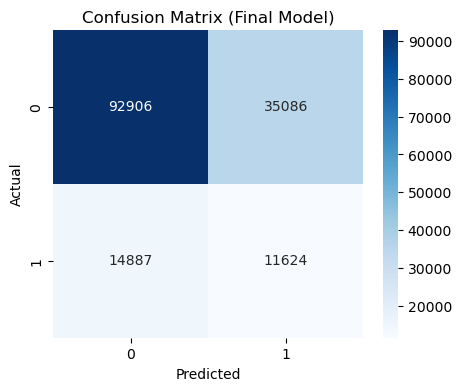

In [ ]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Final Model)")
plt.show()

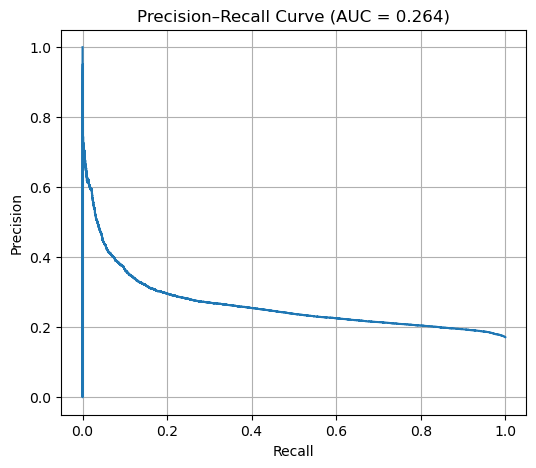

PR-AUC: 0.264


In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_final)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve (AUC = {pr_auc:.3f})")
plt.grid()
plt.show()

print("PR-AUC:", round(pr_auc, 3))

The dataset is highly imbalanced, with only 17% fatal cases.
If the model simply predicted every accident as non-fatal, it would achieve 83% accuracy but detect 0% fatal accidents.
Therefore, accuracy alone is not an appropriate metric for this problem.

Our objective was to improve fatal detection (recall), not maximize raw accuracy.
By lowering the probability threshold to 0.4, we increased fatal recall to 43.8%, meaning the model correctly detects nearly half of fatal accidents.

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame([
    {"Model": "Logistic Regression (balanced)", "Accuracy": 0.583, "Fatal Precision": 0.213, "Fatal Recall": 0.530, "Notes": "Baseline"},
    {"Model": "Random Forest (w={0:1,1:3}, th=0.5)", "Accuracy": 0.813, "Fatal Precision": 0.352, "Fatal Recall": 0.110, "Notes": "High accuracy, low fatal recall"},
    {"Model": "Random Forest (w={0:1,1:3}, th=0.4) FINAL", "Accuracy": 0.677, "Fatal Precision": 0.249, "Fatal Recall": 0.438, "Notes": "Best trade-off, selected"},
    {"Model": "XGBoost (th=0.3)", "Accuracy": 0.815, "Fatal Precision": 0.365, "Fatal Recall": 0.104, "Notes": "Conservative on fatal"},
])

comparison_df

,Model,Accuracy,Fatal Precision,Fatal Recall,Notes
0,Logistic Regression (balanced),0.583,0.213,0.530,Baseline
1,"Random Forest (w={0:1,1:3}, th=0.5)",0.813,0.352,0.110,"High accuracy, low fatal recall"
2,"Random Forest (w={0:1,1:3}, th=0.4) FINAL",0.677,0.249,0.438,"Best trade-off, selected"
3,XGBoost (th=0.3),0.815,0.365,0.104,Conservative on fatal


Achieving very high accuracy is difficult because important real-world variables such as vehicle speed, alcohol involvement, weather conditions, and road surface are not present in the dataset.

In [ ]:
del list

In [ ]:

rf_final = rf_model  


ohe = rf_final.named_steps["prep"].named_transformers_["cat"]
ohe_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = list(ohe_feature_names) + numeric_features

importances = rf_final.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
52,OCC_YEAR,0.214316
51,OCC_HOUR,0.182221
44,PASSENGER_YES,0.083452
53,IS_NIGHT,0.071771
43,PASSENGER_NO,0.058377
55,RUSH_HOUR,0.027491
35,DIVISION_NSA,0.018715
38,AUTOMOBILE_YES,0.015787
54,IS_WEEKEND,0.014841
3,OCC_DOW_Sunday,0.012545


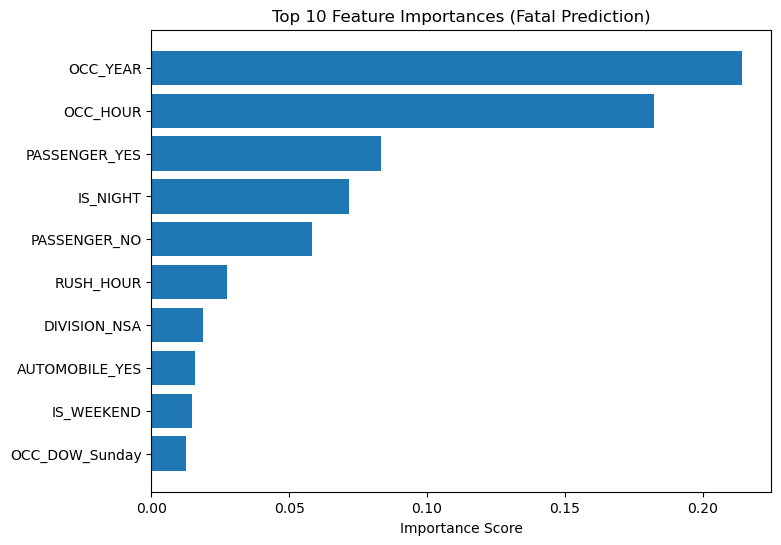

In [ ]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10)

plt.figure(figsize=(8,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Fatal Prediction)")
plt.xlabel("Importance Score")
plt.show()

##  Deployment (Streamlit Application)

The final model was deployed using Streamlit to create an interactive prediction interface.

Users can:

- Enter accident details
- Adjust probability threshold
- View fatal probability
- Receive risk classification

This demonstrates practical application of the trained model.

In [ ]:
from joblib import dump


dump(rf_model, "fatal_rf_model.joblib")
print("Saved model as fatal_rf_model.joblib")

Saved model as fatal_rf_model.joblib


In [ ]:
dataset.columns

Index(['OBJECTID', 'EVENT_UNIQUE_ID', 'OCC_DATE', 'OCC_MONTH', 'OCC_DOW',
       'OCC_YEAR', 'OCC_HOUR', 'DIVISION', 'FATALITIES', 'INJURY_COLLISIONS',
       'FTR_COLLISIONS', 'PD_COLLISIONS', 'HOOD_158', 'NEIGHBOURHOOD_158',
       'LONG_WGS84', 'LAT_WGS84', 'AUTOMOBILE', 'MOTORCYCLE', 'PASSENGER',
       'BICYCLE', 'PEDESTRIAN', 'x', 'y', 'ACCIDENT_SEVERITY', 'IS_NIGHT',
       'IS_WEEKEND', 'RUSH_HOUR', 'FATAL_BINARY'],
      dtype='object')

## Limitations and Future Improvements

Limitations:

- Missing critical features such as speed, weather, alcohol, and road condition.
- Severe class imbalance.
- Year extrapolation beyond training data may reduce reliability.
- Threshold selection depends on policy objectives.

Future Improvements:

- Integrate weather and traffic density data.
- Apply cost-sensitive learning methods.
- Explore LightGBM and ensemble stacking.
- Incorporate real-time traffic data.

## Conclusion

This capstone project developed an end-to-end machine learning solution to estimate **fatal accident risk** from traffic collision records.

Key outcomes:

- Performed data cleaning and feature engineering (e.g., **IS_NIGHT, IS_WEEKEND, RUSH_HOUR**).
- Explored accident patterns using EDA across time, divisions, and road-user involvement.
- Compared multiple models (Logistic Regression, Random Forest, XGBoost) and evaluated performance using metrics suitable for imbalanced data.
- Selected the final model based on the ability to detect fatal cases rather than raw accuracy.

**Final deployed model:**
- Random Forest with `class_weight = {0:1, 1:3}`
- Calibrated decision threshold = **0.40**
- Final performance (Test Set): **Accuracy ≈ 67.7%**, **Fatal Recall ≈ 43.8%**, **Fatal Precision ≈ 24.9%**

Because fatal accidents are a minority class (~17%), maximizing accuracy would lead to poor fatal detection. Therefore, the final model intentionally prioritizes **fatal recall** to better support safety-focused use cases.

Although the model is limited by missing variables such as speed, weather, and alcohol involvement, it demonstrates how machine learning can be applied to accident risk analytics and deployed through an interactive Streamlit web application.

In [ ]:
dataset[dataset['RUSH_HOUR']==1]

,OBJECTID,EVENT_UNIQUE_ID,OCC_DATE,OCC_MONTH,OCC_DOW,OCC_YEAR,OCC_HOUR,DIVISION,FATALITIES,INJURY_COLLISIONS,...,PASSENGER,BICYCLE,PEDESTRIAN,x,y,ACCIDENT_SEVERITY,IS_NIGHT,IS_WEEKEND,RUSH_HOUR,FATAL_BINARY
0,1,GO-20148000028,2014-01-01 05:00:00,January,Wednesday,2014,17,D53,0,NO,...,NO,NO,NO,-8.836276e+06,5.419322e+06,2,0,0,1,1
6,7,GO-20141261510,2014-01-01 05:00:00,January,Wednesday,2014,8,NSA,0,NO,...,NO,NO,NO,6.327780e-09,5.664924e-09,0,0,0,1,0
7,8,GO-20141261523,2014-01-01 05:00:00,January,Wednesday,2014,8,NSA,0,NO,...,NO,NO,NO,6.327780e-09,5.664924e-09,0,0,0,1,0
8,9,GO-20141261626,2014-01-01 05:00:00,January,Wednesday,2014,9,NSA,0,NO,...,NO,NO,NO,6.327780e-09,5.664924e-09,0,0,0,1,0
9,10,GO-20141261706,2014-01-01 05:00:00,January,Wednesday,2014,9,NSA,0,YES,...,YES,NO,NO,6.327780e-09,5.664924e-09,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772497,772498,GO-20252057930,2025-09-30 04:00:00,September,Tuesday,2025,18,D14,0,YES,...,NO,YES,NO,-8.839625e+06,5.410346e+06,1,0,0,1,0
772499,772500,GO-20252057742,2025-09-30 04:00:00,September,Tuesday,2025,16,D23,0,NO,...,NO,NO,NO,-8.863262e+06,5.422667e+06,2,0,0,1,1
772500,772501,GO-20252057716,2025-09-30 04:00:00,September,Tuesday,2025,17,D51,0,YES,...,NO,NO,NO,-8.834926e+06,5.412694e+06,1,0,0,1,0
772501,772502,GO-20252057559,2025-09-30 04:00:00,September,Tuesday,2025,16,D11,0,NO,...,YES,NO,NO,-8.846691e+06,5.411786e+06,2,0,0,1,1


In [ ]:
dataset['IS_INJURY'] = (dataset['ACCIDENT_SEVERITY'] > 0).astype(int)

In [ ]:
print(dataset.groupby('RUSH_HOUR')['IS_INJURY'].mean()*100)
dataset.groupby('RUSH_HOUR')['FATAL_BINARY'].mean()*100

RUSH_HOUR
0    31.459858
1    28.276826
Name: IS_INJURY, dtype: float64


RUSH_HOUR
0    18.522400
1    14.897336
Name: FATAL_BINARY, dtype: float64

In [ ]:
dataset[dataset['FATAL_BINARY']==1].groupby('RUSH_HOUR').size()

RUSH_HOUR
0    89260
1    43293
dtype: int64

## Hypothesis Testing


## H1: Injury collisions occur more frequently during peak rush hours than non-peak hours.

In [ ]:
import scipy.stats as stats
import pandas as pd


contingency_table = pd.crosstab(dataset['RUSH_HOUR'], dataset['IS_INJURY'])

print(contingency_table)


chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("P-value:", p)

IS_INJURY       0       1
RUSH_HOUR                
0          330297  151606
1          208434   82175
Chi-square statistic: 870.1610445602084
P-value: 3.010042048031023e-191


In [ ]:
dataset.groupby('RUSH_HOUR')['IS_INJURY'].mean()*100

RUSH_HOUR
0    31.459858
1    28.276826
Name: IS_INJURY, dtype: float64

The chi-square test produced the following result:

χ² = 870.16

p-value < 0.001

## Interpretation

The results indicate a statistically significant association between rush hour and injury occurrence. However, proportional analysis revealed that the injury rate per collision was slightly lower during rush hours compared to non-rush hours. This suggests that although traffic volume is higher during peak periods, injury likelihood per collision does not increase proportionally.

## Conclusion for H1

Hypothesis 1 is partially supported. While injury outcomes are significantly associated with rush hour timing, injuries are not necessarily more frequent during rush hours on a proportional basis.

## H2:  A small number of neighbourhoods account for a disproportionate share of severe collisions.

In [ ]:
severity_by_neigh = dataset[dataset['IS_INJURY'] == 1] \
                        .groupby('NEIGHBOURHOOD_158') \
                        .size() \
                        .sort_values(ascending=False)

print(severity_by_neigh.head(10))

NEIGHBOURHOOD_158
NSA                             30936
Wexford/Maryvale (119)           5724
West Humber-Clairville (1)       5407
York University Heights (27)     3987
Yorkdale-Glen Park (31)          3489
Etobicoke City Centre (159)      3472
Milliken (130)                   3338
Dorset Park (126)                3263
Bendale-Glen Andrew (156)        2994
Woburn North (142)               2944
dtype: int64


In [ ]:
total_severe = severity_by_neigh.sum()

percentage = (severity_by_neigh / total_severe) * 100

result_df = pd.DataFrame({
    'Severe_Collisions': severity_by_neigh,
    'Percentage_of_Total': percentage
})

print(result_df.head(10))

                              Severe_Collisions  Percentage_of_Total
NEIGHBOURHOOD_158                                                   
NSA                                       30936            13.232897
Wexford/Maryvale (119)                     5724             2.448445
West Humber-Clairville (1)                 5407             2.312848
York University Heights (27)               3987             1.705442
Yorkdale-Glen Park (31)                    3489             1.492422
Etobicoke City Centre (159)                3472             1.485151
Milliken (130)                             3338             1.427832
Dorset Park (126)                          3263             1.395751
Bendale-Glen Andrew (156)                  2994             1.280686
Woburn North (142)                         2944             1.259298


In [ ]:
cumulative_percentage = percentage.cumsum()

pareto_df = pd.DataFrame({
    'Severe_Collisions': severity_by_neigh,
    'Percentage': percentage,
    'Cumulative_%': cumulative_percentage
})

print(pareto_df.head(20))

                                             Severe_Collisions  Percentage  \
NEIGHBOURHOOD_158                                                            
NSA                                                      30936   13.232897   
Wexford/Maryvale (119)                                    5724    2.448445   
West Humber-Clairville (1)                                5407    2.312848   
York University Heights (27)                              3987    1.705442   
Yorkdale-Glen Park (31)                                   3489    1.492422   
Etobicoke City Centre (159)                               3472    1.485151   
Milliken (130)                                            3338    1.427832   
Dorset Park (126)                                         3263    1.395751   
Bendale-Glen Andrew (156)                                 2994    1.280686   
Woburn North (142)                                        2944    1.259298   
South Riverdale (70)                                      2930  

In [ ]:
neigh_50 = cumulative_percentage[cumulative_percentage <= 50].count()
print("Number of neighbourhoods accounting for 50% of severe collisions:", neigh_50)

total_neigh = len(severity_by_neigh)
print("Total neighbourhoods:", total_neigh)



Number of neighbourhoods accounting for 50% of severe collisions: 32
Total neighbourhoods: 159


In [ ]:
import numpy as np

def gini(array):
    array = np.sort(array)
    n = len(array)
    return (2 * np.sum((np.arange(1, n+1) * array))) / (n * np.sum(array)) - (n+1)/n

gini_value = gini(severity_by_neigh.values)

print("Gini Coefficient:", gini_value)

Gini Coefficient: 0.4237133828873172


## Results
Total neighbourhoods analyzed: 159
Neighbourhoods accounting for 50% of severe collisions: 32

This indicates that approximately 20% of neighbourhoods account for 50% of all injury and fatal collisions.

## Interpretation

The distribution of severe collisions is highly uneven and demonstrates strong spatial concentration. Severe collisions are not uniformly distributed across the city but are clustered within a relatively small number of neighbourhoods.

## Conclusion for H2

Hypothesis 2 is strongly supported. The findings suggest that targeted, location-specific safety interventions could be more effective than city-wide strategies

## H3: Collisions involving pedestrians or cyclists have a higher probability of injury or fatal outcomes compared to vehicle-only collisions.

In [ ]:
dataset.groupby(['PEDESTRIAN',"BICYCLE"])["FATAL_BINARY"].mean()

PEDESTRIAN  BICYCLE
N/R         N/R        0.302735
NO          NO         0.169328
            YES        0.172690
YES         NO         0.213503
            YES        0.145631
Name: FATAL_BINARY, dtype: float64

### Conclusion for H3: Road Users and Accident Severity

To test whether pedestrian and bicycle collisions are associated with higher accident severity, we computed the fatal rate across combinations of pedestrian and bicycle involvement.

The fatal probability for accidents without pedestrians or bicycles is approximately 16.9%.  
Accidents involving pedestrians show a higher fatal probability of approximately 21.35%, indicating increased severity.  

Bicycle collisions show a fatal rate similar to the baseline (~17.3%), suggesting only a marginal difference.

These findings partially support the hypothesis that vulnerable road users are associated with higher accident severity, particularly for pedestrian collisions.

## H4: Machine learning models will outperform logistic regression in predicting injury outcomes based on F1-score and ROC-AUC.

In [ ]:

leakage_cols = [
  
    "IS_INJURY",
    "ACCIDENT_SEVERITY",
    "FATAL_BINARY",
    "INJURY_COLLISIONS",
    "FATALITIES",
    "FTR_COLLISIONS",
    "PD_COLLISIONS",

    "OBJECTID",
    "EVENT_UNIQUE_ID"
]

In [ ]:
target = "IS_INJURY"

X = dataset.drop(columns=leakage_cols, errors="ignore")
y = dataset[target]

X.shape, y.value_counts(normalize=True)

((772512, 21),
 IS_INJURY
 0    0.697376
 1    0.302624
 Name: proportion, dtype: float64)

In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

In [ ]:


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_features = X_train.select_dtypes(include=["int64","int32","float64","float32"]).columns
cat_features = X_train.select_dtypes(include=["object"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

In [ ]:


from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score

log_clf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

log_clf.fit(X_train, y_train)

y_pred_log = log_clf.predict(X_test)
y_prob_log = log_clf.predict_proba(X_test)[:,1]

f1_logistic = f1_score(y_test, y_pred_log)
auc_logistic = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression -> F1:", f1_logistic, "ROC-AUC:", auc_logistic)

Logistic Regression -> F1: 0.27912884206585825 ROC-AUC: 0.6227215995477515


In [ ]:


from sklearn.ensemble import RandomForestClassifier

rf_clf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=14,
        random_state=42,
        n_jobs=-1
    ))
])

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:,1]

f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest -> F1:", f1_rf, "ROC-AUC:", auc_rf)

Random Forest -> F1: 0.2645821301872783 ROC-AUC: 0.6426788262326704


In [ ]:


print("\nMODEL COMPARISON")
print(f"Logistic Regression | F1={f1_logistic:.4f} | ROC-AUC={auc_logistic:.4f}")
print(f"Random Forest       | F1={f1_rf:.4f} | ROC-AUC={auc_rf:.4f}")

if (f1_rf > f1_logistic) and (auc_rf > auc_logistic):
    print("Conclusion: H4 Supported")
elif (f1_rf > f1_logistic) or (auc_rf > auc_logistic):
    print("Conclusion: H4 Partially Supported")
else:
    print("Conclusion: H4 Not Supported")


MODEL COMPARISON
Logistic Regression | F1=0.2791 | ROC-AUC=0.6227
Random Forest       | F1=0.2646 | ROC-AUC=0.6427
Conclusion: H4 Partially Supported


## Model Performance Comparison

Hypothesis 4 examined whether machine learning models outperform logistic regression in predicting injury outcomes. Logistic regression was used as a baseline model and compared with a Random Forest model using a leakage-free feature set consisting only of pre-collision variables. Model performance was evaluated using F1-score and ROC-AUC.

Logistic regression achieved an F1-score of 0.2791 and a ROC-AUC of 0.6227, while the Random Forest model achieved an F1-score of 0.2646 and a ROC-AUC of 0.6427. This indicates that logistic regression performed better at classifying injury cases, whereas the Random Forest model showed better overall discrimination.

## Conclusion for H4

Hypothesis 4 is partially supported. While the Random Forest model outperformed logistic regression in terms of ROC-AUC, logistic regression achieved a higher F1-score, indicating that machine learning models do not consistently outperform traditional statistical models across all performance metrics.